# Model Selection

## Table of Contents
1. [Introduction](#1-Introduction)
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Clustering with Standard Scaler](#2-clustering-with-standard-scaler)
   - 3.1 K-Means
   - 3.2 Mean Shift
   - 3.3 Hierarchical Clustering
   - 3.4 DBSCAN
   - 3.5 SOM (Self-Organizing Map)
3. [Clustering with Robust Scaler](#3-clustering-with-robust-scaler)
   - 4.1 K-Means
   - 4.2 Mean Shift
   - 4.3 Hierarchical Clustering
   - 4.4 DBSCAN
   - 4.5 SOM (Self-Organizing Map)
4. [Clustering with MinMax Scaler](#4-clustering-with-minmax-scaler)
   - 5.1 K-Means
   - 5.2 Mean Shift
   - 5.3 Hierarchical Clustering
   - 5.4 DBSCAN
   - 5.5 SOM (Self-Organizing Map)


# 1. Introduction
> **Note:** This notebook serves as our exploratory workspace for model selection and parameter tuning.

Throughout this document, we present our iterative process of finding the optimal clustering architecture. Here, we tested various clustering algorithms (such as K-Means, Hierarchical Clustering, DBSCAN, Mean Shift, and SOM), and evaluated multiple scaling techniques (Standard, Robust, and MinMax Scaler) to observe how they impacted cluster separation.
Our goal in this notebook was to robustly evaluate different configurations using internal validation metrics (like the Silhouette Score) to ensure the mathematical validity of our segments. 
The final, optimized models selected from these extensive tests—along with the comprehensive business profiling and final conclusions—are presented in the `final_notebook.ipynb` deliverable.

# 1. Setup & Data Loading

In [1]:
# Import necessary libraries for data processing and visualization
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Import all clustering algorithms and helper functions from Clustering.py
import importlib
import Clustering
importlib.reload(Clustering)
from Clustering import (
    find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, 
    fit_dbscan,fit_som, 
    get_som_cluster_labels, assign_som_clusters, fit_meanshift, plot_umap, plot_tsne
)

# Import preprocessing functions from Preprocessing.py
from Preprocessing import (
    preprocess_data_standardscaler, preprocess_data_robustscaler, 
    preprocess_data_minmaxscaler, cluster_analysis
)

In [3]:
df = pd.read_csv('customer_info_engineered.csv')

In [4]:
df=df[['loyalty_product_type', 'lifetime_spend_vegetables_prop', 'lifetime_spend_meat_prop', 'lifetime_spend_hygiene_prop', 'lifetime_spend_videogames_prop', 'lifetime_spend_petfood_prop']]

df


,loyalty_product_type,lifetime_spend_vegetables_prop,lifetime_spend_meat_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop
0,98.359788,0.020065,0.001506,0.029693,0.013771,0.020656
1,155.638462,0.099442,0.002125,0.092918,0.016458,0.032867
2,191.962963,0.035694,0.081356,0.032607,0.006496,0.014277
3,162.521739,0.005618,0.065008,0.032437,0.110754,0.012306
4,4299.500000,0.014730,0.041400,0.011513,0.048765,0.017095
...,...,...,...,...,...,...
33033,122.962963,0.009538,0.051205,0.003112,0.080221,0.018373
33034,304.329897,0.009858,0.044817,0.007453,0.071308,0.007690
33035,68.412621,0.113532,0.021784,0.121975,0.006315,0.018307
33036,35.807792,0.043232,0.000000,0.029740,0.000000,0.016321


In [5]:
# Preprocess and scale the dataset using Standard, Robust, and MinMax scalers
df_processed_st = preprocess_data_standardscaler(df)
df_processed_rb = preprocess_data_robustscaler(df)
df_processed_mm = preprocess_data_minmaxscaler(df)

# 2. Clustering with Standard Scaler

## 2.1 K-Means

k=2 | Inertia: 157627.40 | Silhouette: 0.3828
k=3 | Inertia: 133409.13 | Silhouette: 0.3680
k=4 | Inertia: 112288.45 | Silhouette: 0.3933
k=5 | Inertia: 93727.65 | Silhouette: 0.3952
k=6 | Inertia: 85104.30 | Silhouette: 0.2745
k=7 | Inertia: 77366.09 | Silhouette: 0.2853
k=8 | Inertia: 72714.25 | Silhouette: 0.2859
k=9 | Inertia: 69062.14 | Silhouette: 0.2869
k=10 | Inertia: 64521.93 | Silhouette: 0.2430


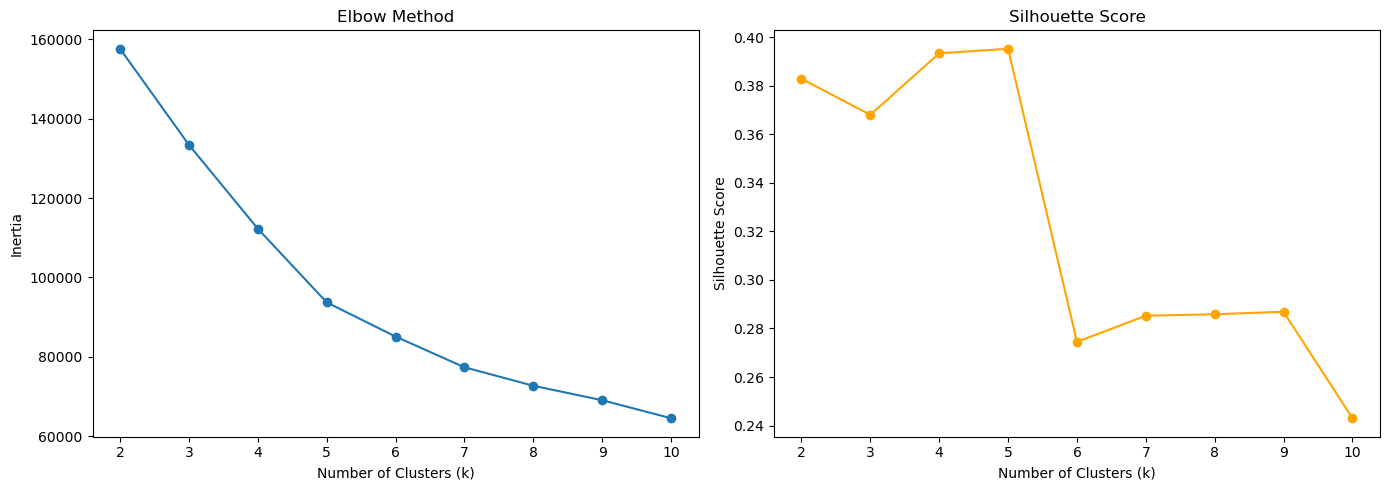

In [8]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_st)

In [9]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_st = fit_kmeans(df_processed_st, 5)
print(kmeans_profile_st)

Silhouette Score: 0.3952
Cluster sizes:
0     3041
1    20740
2     3288
3     5871
4       98
Name: count, dtype: int64
                                cluster_0  cluster_1  cluster_2  cluster_3  \
loyalty_product_type            -0.113364  -0.033995   0.054624  -0.083507   
lifetime_spend_vegetables_prop   0.191069  -0.387378  -0.567528   1.588859   
lifetime_spend_meat_prop         1.989615  -0.064126   0.221247  -0.925135   
lifetime_spend_hygiene_prop      0.600519  -0.336370  -0.669226   1.258055   
lifetime_spend_videogames_prop   0.154994  -0.342388   2.466462  -0.258333   
lifetime_spend_petfood_prop      1.699330  -0.319584  -0.238515   0.383516   

                                cluster_4  
loyalty_product_type            13.882359  
lifetime_spend_vegetables_prop  -0.091581  
lifetime_spend_meat_prop        -0.167860  
lifetime_spend_hygiene_prop     -0.362243  
lifetime_spend_videogames_prop   0.374883  
lifetime_spend_petfood_prop     -0.070124  


In [10]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_st = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans_st = kmeans_opt_st.fit_predict(df_processed_st)

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


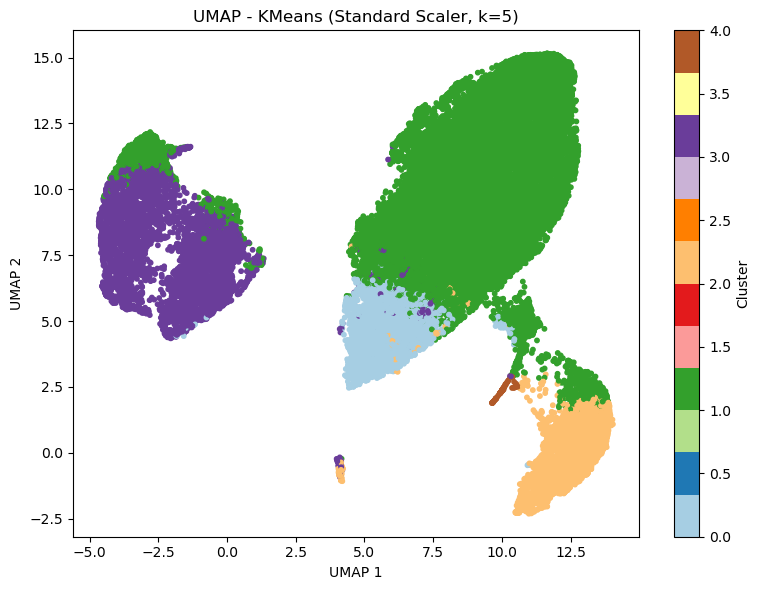

array([[ 6.811028  , 12.140167  ],
       [-0.12784512,  6.4598346 ],
       [ 8.757871  ,  5.7785864 ],
       ...,
       [-1.2173804 ,  6.769906  ],
       [ 7.0075645 , 12.806334  ],
       [ 6.5872645 ,  4.6630106 ]], shape=(33038, 2), dtype=float32)

In [11]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_kmeans_st, title="UMAP - KMeans (Standard Scaler, k=5)")

In [ ]:
plot_tsne(df_processed_st, labels_kmeans_st, title="TSNE - KMeans (Standard Scaler, k=5)")

## 2.2 Mean Shift

In [ ]:
# Fit Mean Shift clustering to automatically determine the number of clusters
labels_ms_st = fit_meanshift(df_processed_st, bin_seeding=True)

print("Standard Scaler MeanShift cluster count:", len(np.unique(labels_ms_st)))
if len(np.unique(labels_ms_st)) > 1:
    print(f"Standard Scaler MeanShift silhouette: {silhouette_score(df_processed_st, labels_ms_st):.4f}")
else:
    print("Standard Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_st).value_counts().sort_index())


Standard Scaler MeanShift cluster count: 74
Standard Scaler MeanShift silhouette: 0.3720
0     30772
1        28
2        11
3       107
4        82
      ...  
69        1
70        1
71        1
72        7
73        1
Name: count, Length: 74, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


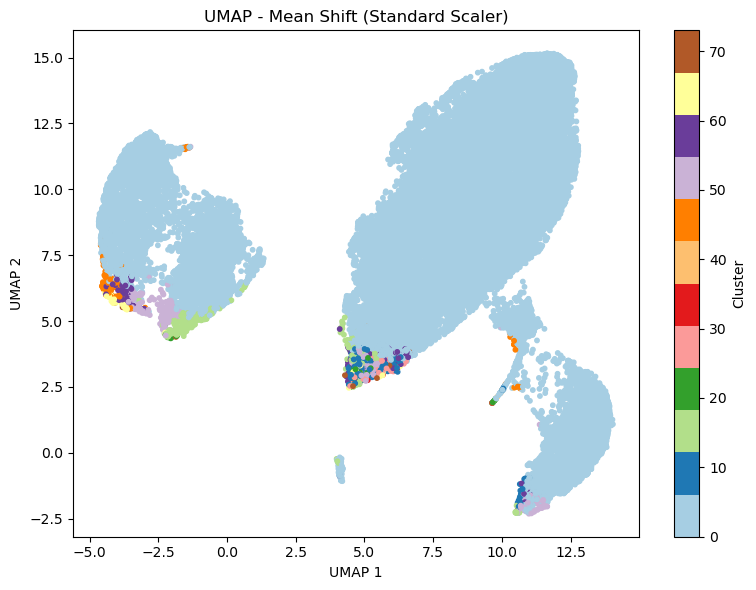

array([[ 6.811028  , 12.140167  ],
       [-0.12784512,  6.4598346 ],
       [ 8.757871  ,  5.7785864 ],
       ...,
       [-1.2173804 ,  6.769906  ],
       [ 7.0075645 , 12.806334  ],
       [ 6.5872645 ,  4.6630106 ]], shape=(33038, 2), dtype=float32)

In [13]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_ms_st, title="UMAP - Mean Shift (Standard Scaler)")

## 2.3 Hierarchical Clustering

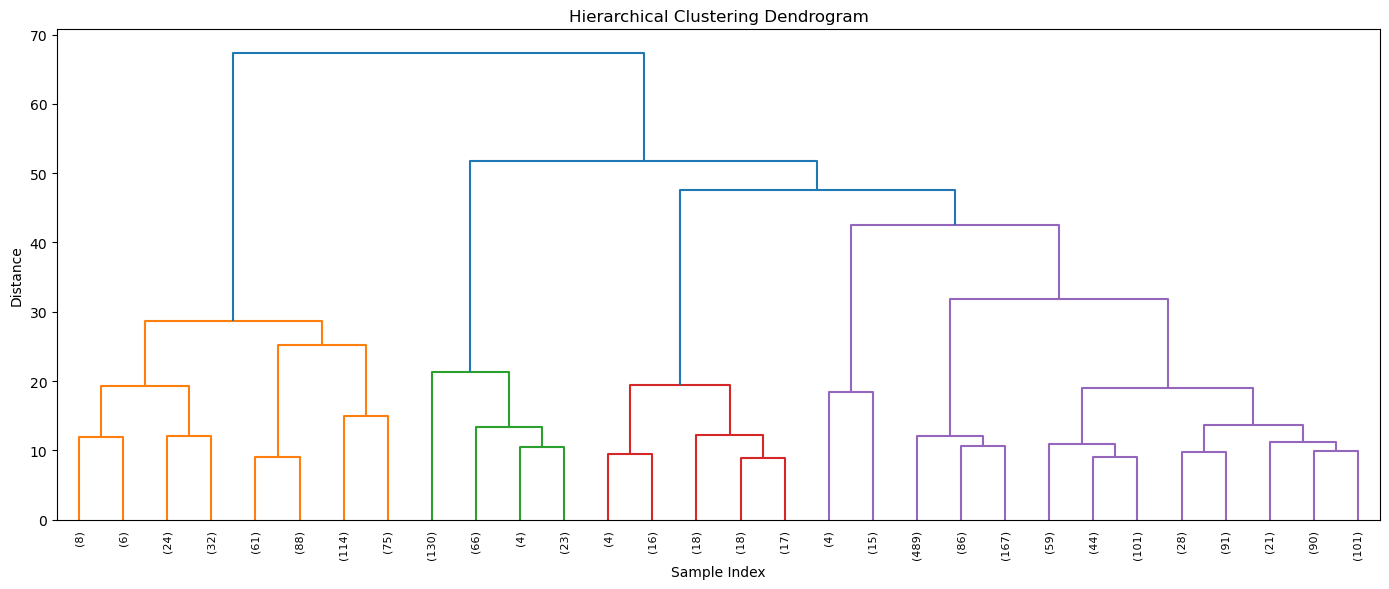

Silhouette Score: 0.3213
Cluster sizes:
0     6893
1      103
2     5291
3     2447
4    18304
Name: count, dtype: int64


In [14]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_st, labels_hierarchical_st, cluster_profile_hierarchical_st = fit_hierarchical(df_processed_st, 5, method='ward')

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


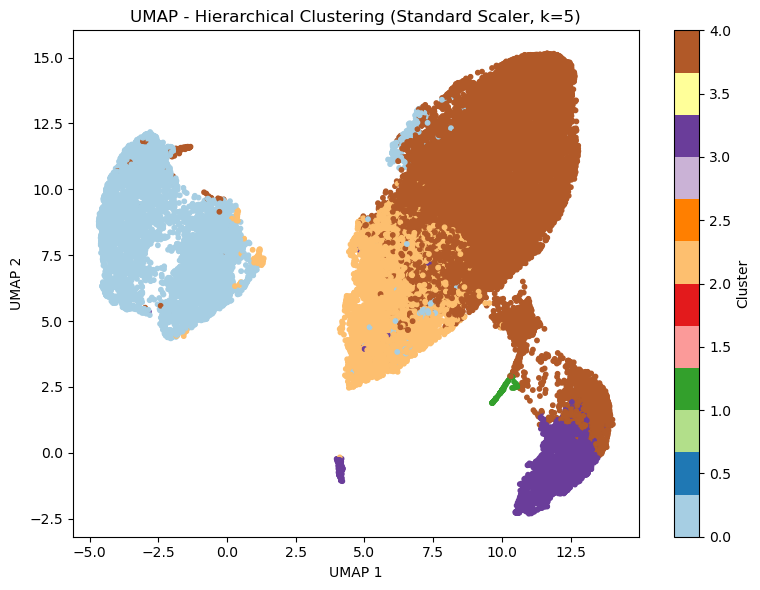

array([[ 6.811028  , 12.140167  ],
       [-0.12784512,  6.4598346 ],
       [ 8.757871  ,  5.7785864 ],
       ...,
       [-1.2173804 ,  6.769906  ],
       [ 7.0075645 , 12.806334  ],
       [ 6.5872645 ,  4.6630106 ]], shape=(33038, 2), dtype=float32)

In [15]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_hierarchical_st, title="UMAP - Hierarchical Clustering (Standard Scaler, k=5)")

In [ ]:
plot_tsne(df_processed_st, labels_hierarchical_st, title="TSNE - Hierarchical Clustering (Standard Scaler, k=5)")

## 2.4 DBSCAN

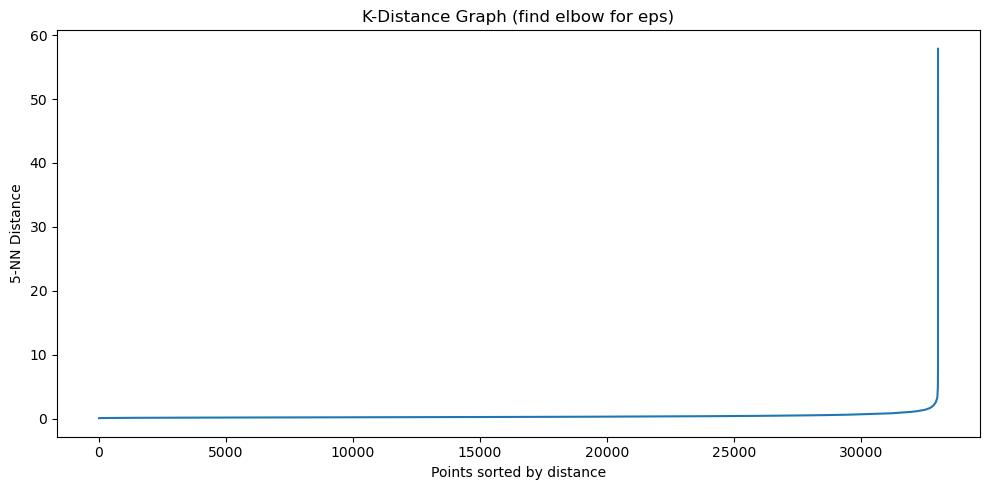

In [16]:
#Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_st, n_neighbors=5)

In [17]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_st, 2.5, min_samples=5))

Number of clusters: 2
Noise points: 47 (0.14%)
Silhouette Score (excluding noise): 0.8675
Cluster sizes:
-1       47
 0    32980
 1       11
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_st, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 20 (0.06%)
Cluster sizes:
-1       20
 0    33018
Name: count, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


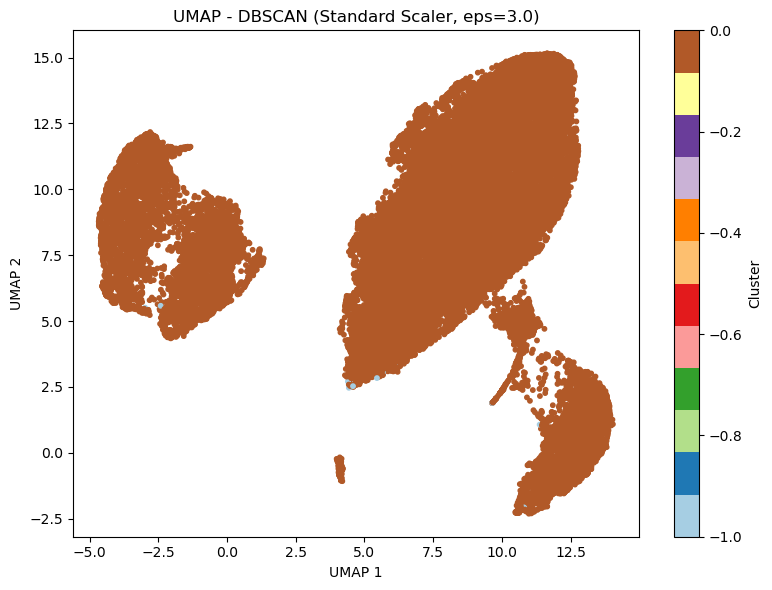

array([[ 6.811028  , 12.140167  ],
       [-0.12784512,  6.4598346 ],
       [ 8.757871  ,  5.7785864 ],
       ...,
       [-1.2173804 ,  6.769906  ],
       [ 7.0075645 , 12.806334  ],
       [ 6.5872645 ,  4.6630106 ]], shape=(33038, 2), dtype=float32)

In [18]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_st, labels_dbscan_st = fit_dbscan(df_processed_st, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_dbscan_st, title="UMAP - DBSCAN (Standard Scaler, eps=3.0)")

In [ ]:
plot_tsne(df_processed_st, labels_dbscan_st, title="TSNE - DBSCAN (Standard Scaler, eps=3.0)")

## 2.5 Self-Organizing Map (SOM)

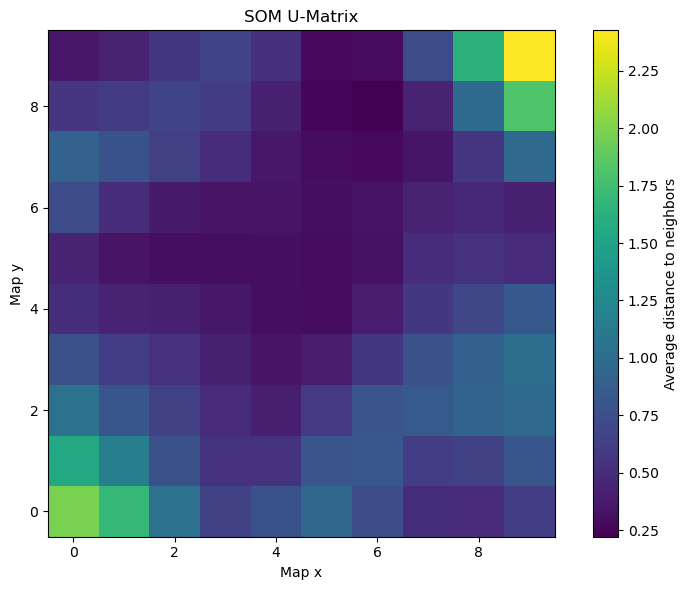

Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


SOM cluster count: 5
SOM silhouette: 0.3623
Distribuição das amostras pelos clusters:
0     3582
1    20040
2     5068
3     3794
4      554
Name: count, dtype: int64


In [6]:
# 1. Treinar o Self-Organizing Map (SOM)
som_result_st = fit_som(df_processed_st, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=True)

# 2. Obter os clusters finais para os teus clientes (k=5)
labels_som_st, neuron_labels_st = assign_som_clusters(som_result_st['weights'], df_processed_st, n_clusters=5, random_state=42)

# 3. Mostrar os resultados de forma limpa (como fazes nos outros modelos)
print("SOM cluster count:", len(np.unique(labels_som_st)))
print(f"SOM silhouette: {silhouette_score(df_processed_st, labels_som_st):.4f}")
print("Distribuição das amostras pelos clusters:")
print(pd.Series(labels_som_st).value_counts().sort_index())


# 3. Clustering with Robust Scaler

## 3.1 K-Means

k=2 | Inertia: 922269.19 | Silhouette: 0.9538
k=3 | Inertia: 674519.29 | Silhouette: 0.8580
k=4 | Inertia: 465899.34 | Silhouette: 0.8504
k=5 | Inertia: 380256.83 | Silhouette: 0.4933
k=6 | Inertia: 307332.39 | Silhouette: 0.4976
k=7 | Inertia: 252456.05 | Silhouette: 0.5065
k=8 | Inertia: 214219.92 | Silhouette: 0.3726
k=9 | Inertia: 191726.19 | Silhouette: 0.3813
k=10 | Inertia: 174370.08 | Silhouette: 0.3750


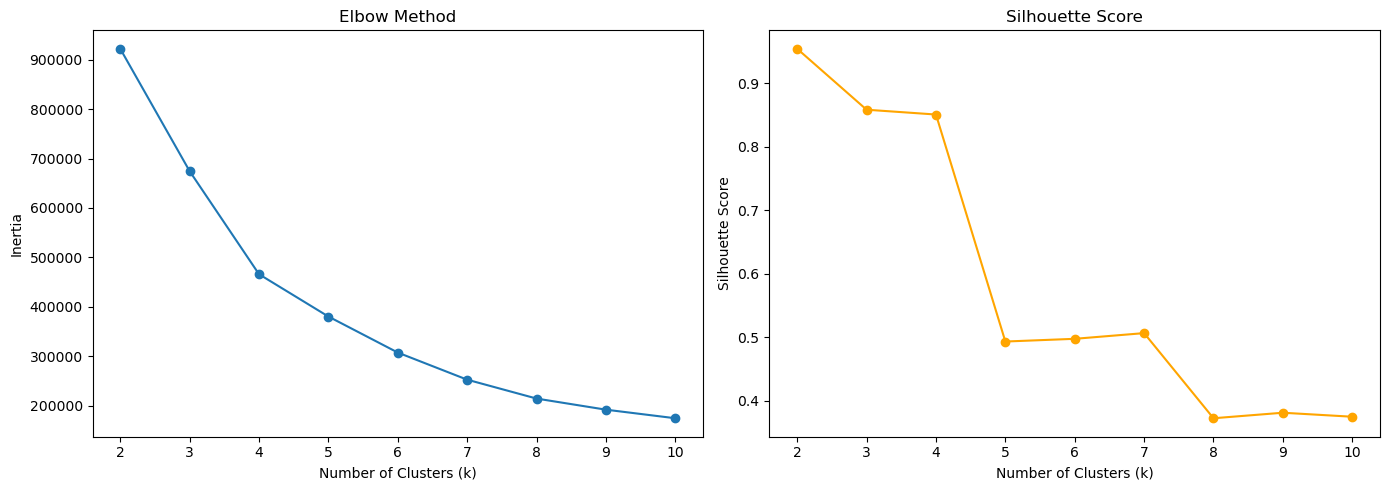

In [23]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_rb)

In [24]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_rb = fit_kmeans(df_processed_rb, 5)
print(kmeans_profile_rb)

Silhouette Score: 0.4933
Cluster sizes:
0     3720
1       72
2      386
3        1
4    28859
Name: count, dtype: int64
                                cluster_0   cluster_1  cluster_2   cluster_3  \
loyalty_product_type             0.889776  105.120910  26.911323  566.906183   
lifetime_spend_vegetables_prop  -0.040291    0.309690   0.251733   -0.258552   
lifetime_spend_meat_prop         0.512394    0.011726   0.101105   -0.643893   
lifetime_spend_hygiene_prop     -0.232276   -0.071924  -0.029339   -0.497993   
lifetime_spend_videogames_prop   5.053877    1.192197   1.006575   -0.152985   
lifetime_spend_petfood_prop      0.245463    0.177296   0.088312   -0.878557   

                                cluster_4  
loyalty_product_type             0.396607  
lifetime_spend_vegetables_prop   0.458564  
lifetime_spend_meat_prop         0.070182  
lifetime_spend_hygiene_prop      0.374908  
lifetime_spend_videogames_prop   0.056755  
lifetime_spend_petfood_prop      0.209727  


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


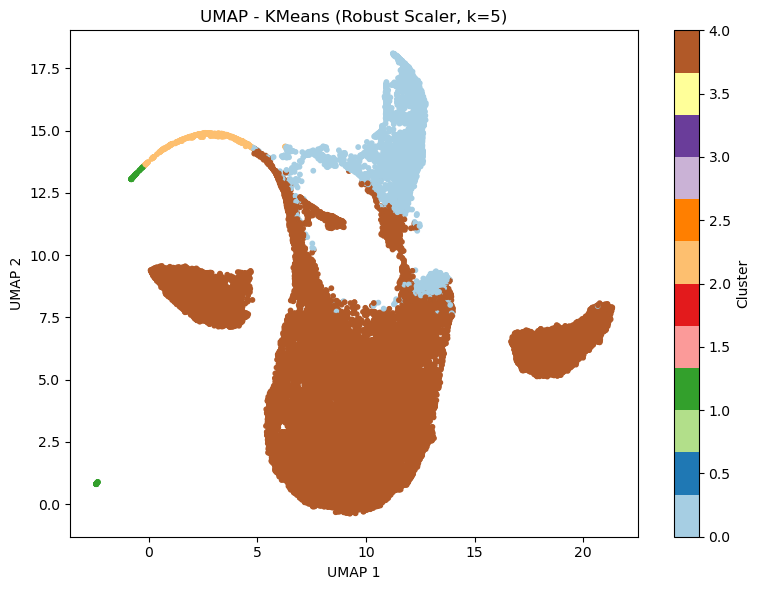

array([[ 9.7369   ,  3.0249918],
       [ 2.6205177,  8.964956 ],
       [10.663879 ,  5.7185006],
       ...,
       [ 2.0087202,  8.10538  ],
       [ 8.891738 ,  2.510032 ],
       [13.452457 ,  6.89132  ]], shape=(33038, 2), dtype=float32)

In [25]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_rb = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans_rb = kmeans_opt_rb.fit_predict(df_processed_rb)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_kmeans_rb, title="UMAP - KMeans (Robust Scaler, k=5)")

In [ ]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_tsne(df_processed_rb, labels_kmeans_rb, title="TSNE - KMeans (Robust Scaler, k=5)")

## 3.2 Mean Shift

In [ ]:
# Fit Mean Shift clustering to automatically determine the number of clusters
labels_ms_rb = fit_meanshift(df_processed_rb, bin_seeding=True)

print("Robust Scaler MeanShift cluster count:", len(np.unique(labels_ms_rb)))
if len(np.unique(labels_ms_rb)) > 1:
    print(f"Robust Scaler MeanShift silhouette: {silhouette_score(df_processed_rb, labels_ms_rb):.4f}")
else:
    print("Robust Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_rb).value_counts().sort_index())



Robust Scaler MeanShift cluster count: 72
Robust Scaler MeanShift silhouette: 0.4437
0     30695
1        81
2        31
3        25
4        21
      ...  
67      123
68        1
69       58
70        1
71        9
Name: count, Length: 72, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


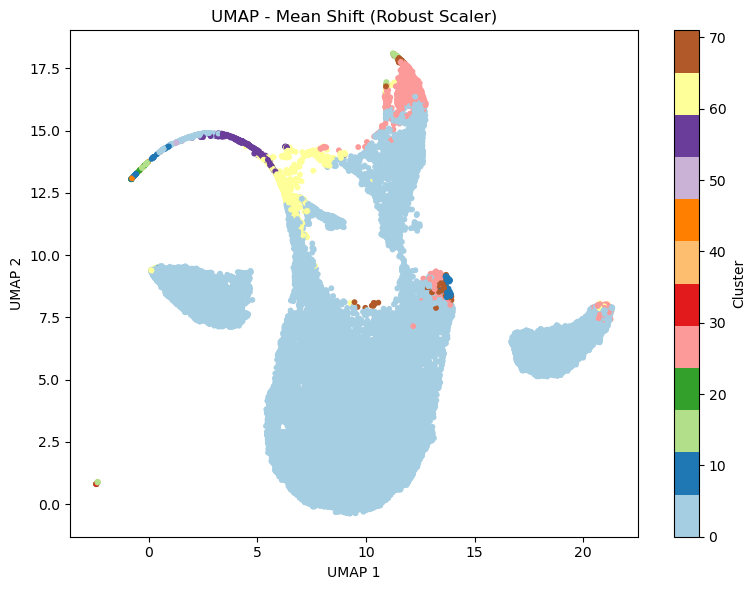

array([[ 9.7369   ,  3.0249918],
       [ 2.6205177,  8.964956 ],
       [10.663879 ,  5.7185006],
       ...,
       [ 2.0087202,  8.10538  ],
       [ 8.891738 ,  2.510032 ],
       [13.452457 ,  6.89132  ]], shape=(33038, 2), dtype=float32)

In [27]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_ms_rb, title="UMAP - Mean Shift (Robust Scaler)")

## 3.3 Hierarchical Clustering

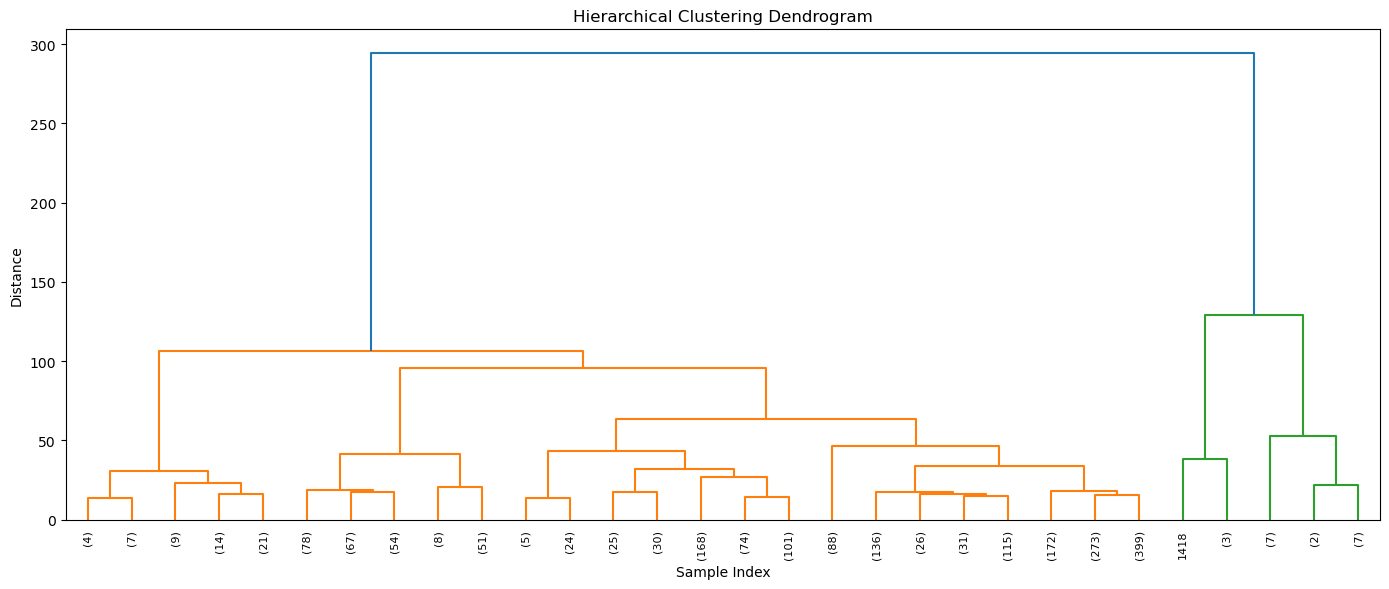

Silhouette Score: 0.5015
Cluster sizes:
0     4288
1       71
2      221
3        1
4    28457
Name: count, dtype: int64


In [28]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_rb, labels_hierarchical_rb, cluster_profile_hierarchical_rb = fit_hierarchical(df_processed_rb, 5, method='ward')

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


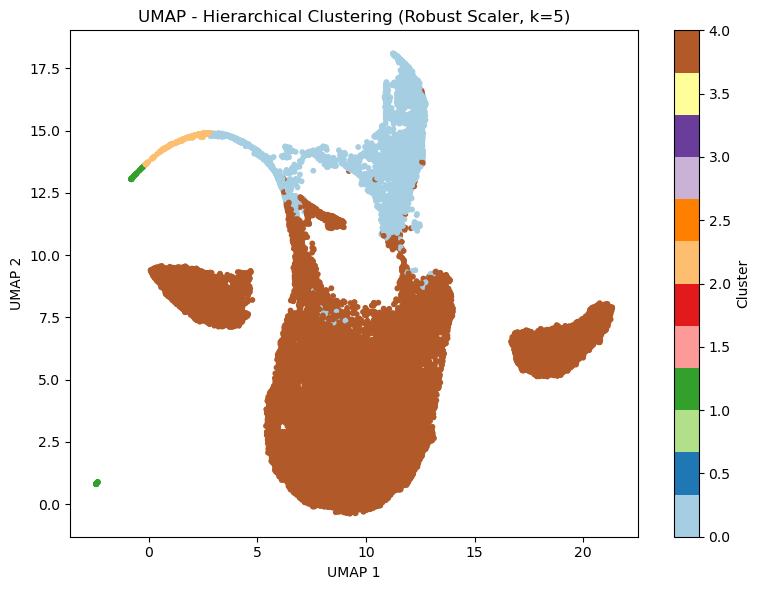

array([[ 9.7369   ,  3.0249918],
       [ 2.6205177,  8.964956 ],
       [10.663879 ,  5.7185006],
       ...,
       [ 2.0087202,  8.10538  ],
       [ 8.891738 ,  2.510032 ],
       [13.452457 ,  6.89132  ]], shape=(33038, 2), dtype=float32)

In [29]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_hierarchical_rb, title="UMAP - Hierarchical Clustering (Robust Scaler, k=5)")

In [ ]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_tsne(df_processed_rb, labels_hierarchical_rb, title="TSNE - Hierarchical Clustering (Robust Scaler, k=5)")

## 3.4 DBSCAN

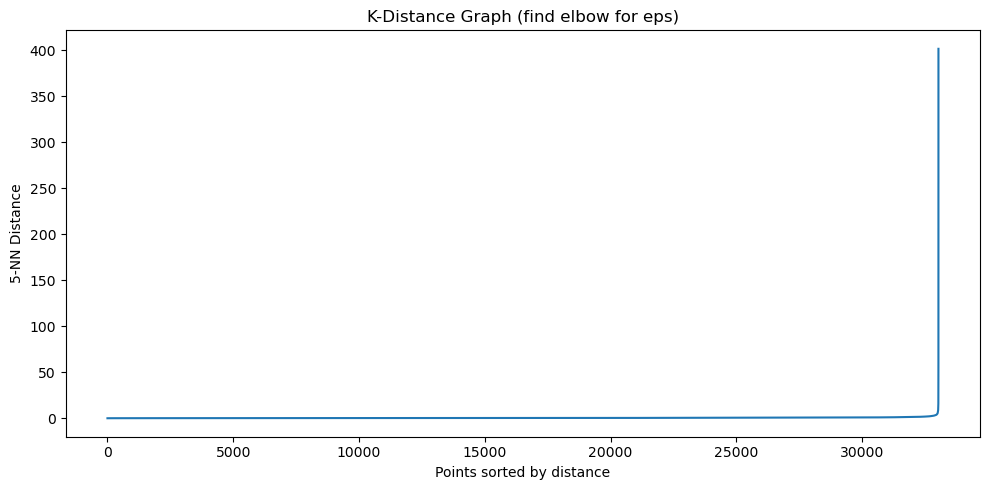

In [30]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_rb, n_neighbors=5)

In [31]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_rb, 2.5, min_samples=5))

Number of clusters: 5
Noise points: 188 (0.57%)
Silhouette Score (excluding noise): 0.9151
Cluster sizes:
-1      188
 0    32820
 1        7
 2        6
 3       12
 4        5
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_rb, 3.5, min_samples=5))

Number of clusters: 7
Noise points: 100 (0.30%)
Silhouette Score (excluding noise): 0.7689
Cluster sizes:
-1      100
 0    32888
 1       15
 2        6
 3        8
 4       12
 5        5
 6        4
Name: count, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


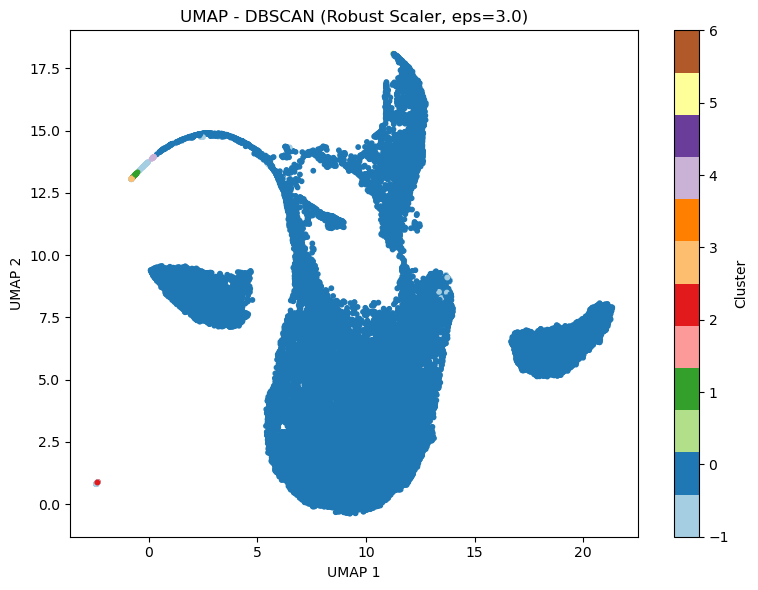

array([[ 9.7369   ,  3.0249918],
       [ 2.6205177,  8.964956 ],
       [10.663879 ,  5.7185006],
       ...,
       [ 2.0087202,  8.10538  ],
       [ 8.891738 ,  2.510032 ],
       [13.452457 ,  6.89132  ]], shape=(33038, 2), dtype=float32)

In [32]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_rb, labels_dbscan_rb = fit_dbscan(df_processed_rb, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_dbscan_rb, title="UMAP - DBSCAN (Robust Scaler, eps=3.0)")

## 3.5 Self-Organizing Map (SOM)

In [34]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_rb = fit_som(df_processed_rb, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100


In [35]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_rb = get_som_cluster_labels(som_result_rb['weights'], n_clusters=5, random_state=42)
print(neuron_labels_rb)

[[2 3 0 0 1 1 1 1 1 1]
 [3 0 0 1 1 1 1 1 1 1]
 [0 0 0 1 1 1 1 1 1 1]
 [0 0 1 1 1 1 1 1 1 1]
 [4 4 1 1 1 1 1 1 1 1]
 [4 4 1 1 1 1 1 1 1 1]
 [4 4 4 1 1 1 1 1 1 1]
 [4 4 4 1 1 1 1 1 1 1]
 [4 4 4 1 1 1 1 1 1 1]
 [4 4 4 1 1 1 1 1 1 1]]


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [36]:
# Assign each data sample to a SOM neuron cluster label
labels_som_rb, neuron_labels_rb = assign_som_clusters(som_result_rb['weights'], df_processed_rb, n_clusters=5, random_state=42)
print((labels_som_rb, neuron_labels_rb))

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(array([1, 1, 1, ..., 1, 1, 1], shape=(33038,), dtype=int32), array([[2, 3, 0, 0, 1, 1, 1, 1, 1, 1],
       [3, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 1, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 1, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 4, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 4, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 4, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 4, 1, 1, 1, 1, 1, 1, 1]], dtype=int32))


# 4. Clustering with MinMax Scaler

## 4.1 K-Means

k=2 | Inertia: 927.81 | Silhouette: 0.4532
k=3 | Inertia: 747.87 | Silhouette: 0.4178
k=4 | Inertia: 638.56 | Silhouette: 0.4184
k=5 | Inertia: 556.55 | Silhouette: 0.4045
k=6 | Inertia: 495.59 | Silhouette: 0.4168
k=7 | Inertia: 450.17 | Silhouette: 0.2966
k=8 | Inertia: 418.79 | Silhouette: 0.2980
k=9 | Inertia: 391.89 | Silhouette: 0.3006
k=10 | Inertia: 371.21 | Silhouette: 0.2911


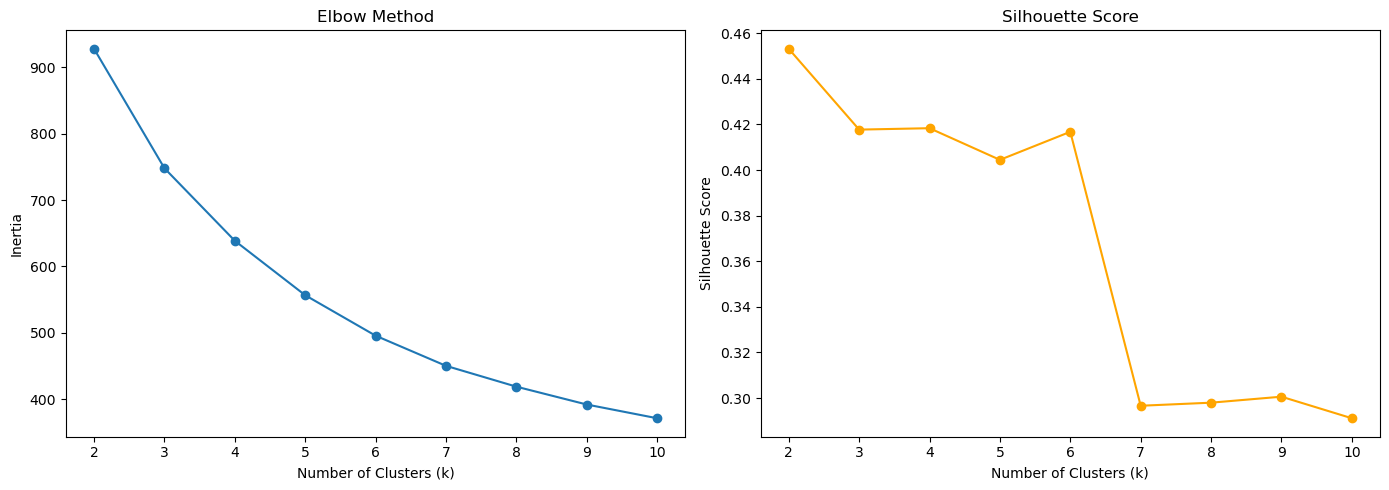

In [37]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_mm)

In [38]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_mm = fit_kmeans(df_processed_mm, 6)
print(kmeans_profile_mm)

Silhouette Score: 0.4168
Cluster sizes:
0     2948
1     3286
2    19678
3     1056
4     2648
5     3422
Name: count, dtype: int64
                                cluster_0  cluster_1  cluster_2  cluster_3  \
loyalty_product_type             0.002429   0.005497   0.003618   0.002177   
lifetime_spend_vegetables_prop   0.208170   0.029143   0.048557   0.514087   
lifetime_spend_meat_prop         0.029338   0.101605   0.083774   0.033944   
lifetime_spend_hygiene_prop      0.316024   0.039129   0.075648   0.284365   
lifetime_spend_videogames_prop   0.034101   0.283766   0.038235   0.100882   
lifetime_spend_petfood_prop      0.114839   0.068160   0.065284   0.162206   

                                cluster_4  cluster_5  
loyalty_product_type             0.002188   0.004207  
lifetime_spend_vegetables_prop   0.125996   0.264790  
lifetime_spend_meat_prop         0.231243   0.021787  
lifetime_spend_hygiene_prop      0.181342   0.103911  
lifetime_spend_videogames_prop   0.085794   0.

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


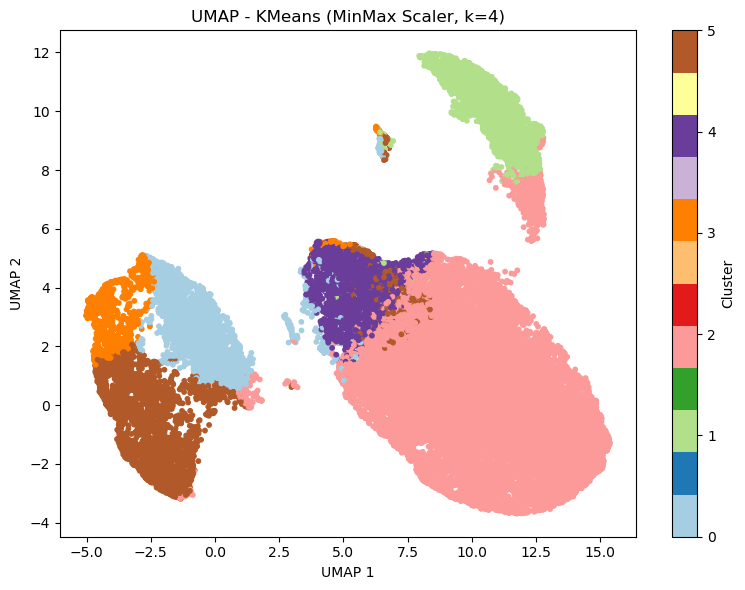

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [39]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_mm = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans_mm = kmeans_opt_mm.fit_predict(df_processed_mm)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_kmeans_mm, title="UMAP - KMeans (MinMax Scaler, k=4)")

## 4.2 Mean Shift

In [42]:
# Fit Mean Shift clustering to automatically determine the number of clusters
labels_ms_mm = fit_meanshift(df_processed_mm, bin_seeding=True)

print("MinMax Scaler MeanShift cluster count:", len(np.unique(labels_ms_mm)))
if len(np.unique(labels_ms_mm)) > 1:
    print(f"MinMax Scaler MeanShift silhouette: {silhouette_score(df_processed_mm, labels_ms_mm):.4f}")
else:
    print("MinMax Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_mm).value_counts().sort_index())



MeanShift found 48 clusters.
MinMax Scaler MeanShift cluster count: 48
MinMax Scaler MeanShift silhouette: 0.3693
0     30525
1        28
2        12
3        21
4        82
5        47
6        12
7       275
8         3
9        47
10      132
11        8
12       56
13        4
14       17
15        4
16       21
17        8
18        2
19       28
20       31
21        1
22       12
23      109
24       15
25        4
26        1
27        1
28      123
29      203
30      769
31       32
32        1
33        5
34        1
35        1
36       21
37       27
38       63
39        1
40        1
41       10
42        1
43        2
44        1
45       26
46      243
47        1
Name: count, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


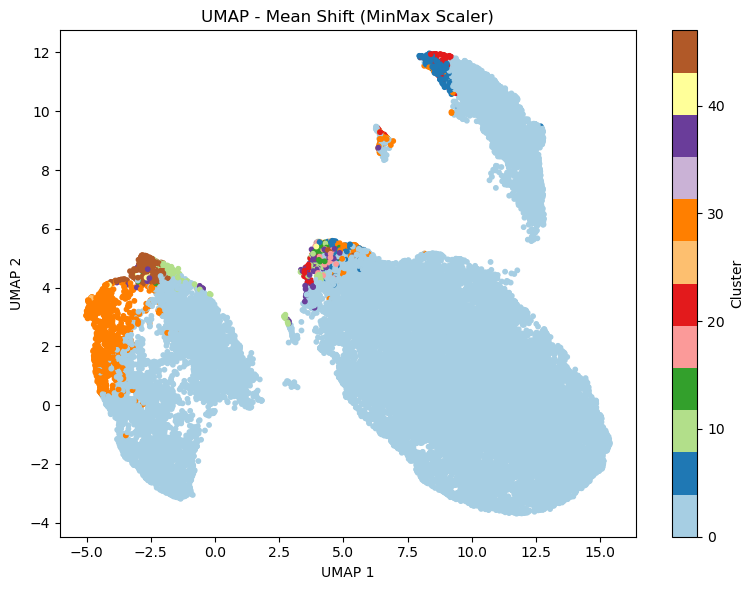

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [43]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_ms_mm, title="UMAP - Mean Shift (MinMax Scaler)")

## 4.3 Hierarchical Clustering

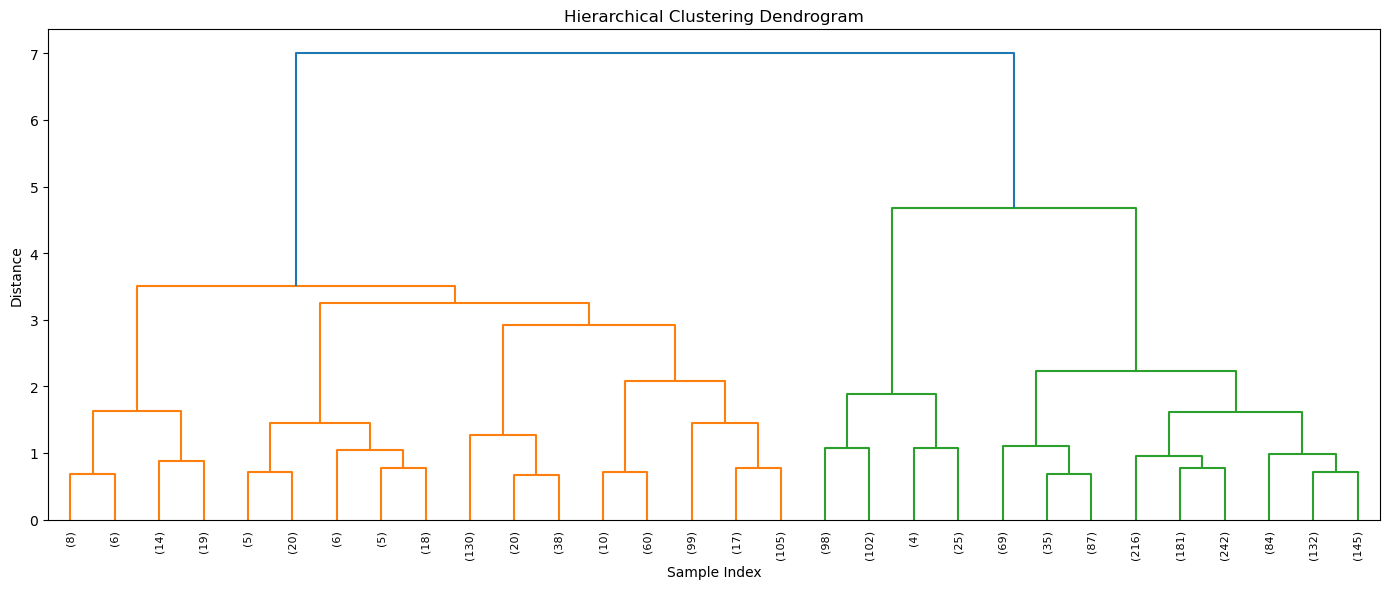

Silhouette Score: 0.3788
Cluster sizes:
0    21008
1     3111
2     3911
3     1467
4      993
5     2548
Name: count, dtype: int64


In [44]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_mm, labels_hierarchical_mm, cluster_profile_hierarchical_mm = fit_hierarchical(df_processed_mm, 6, method='ward')

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


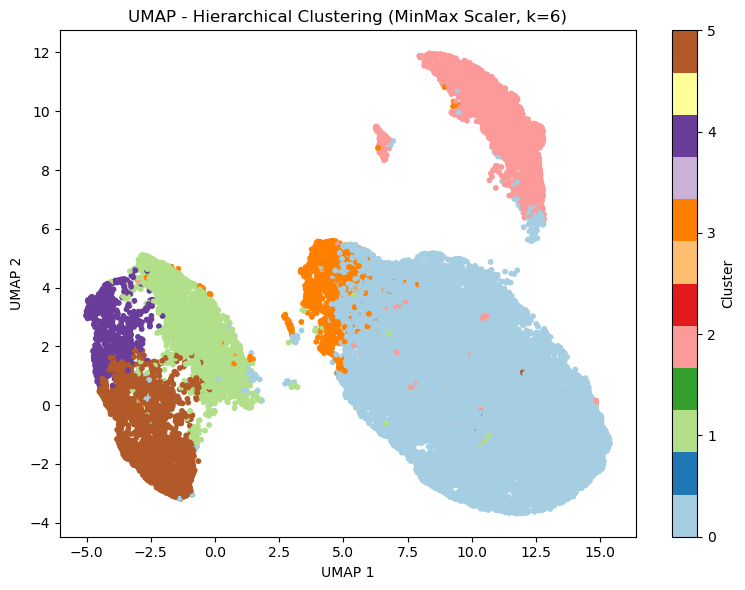

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [45]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_hierarchical_mm, title="UMAP - Hierarchical Clustering (MinMax Scaler, k=6)")

## 4.4 DBSCAN

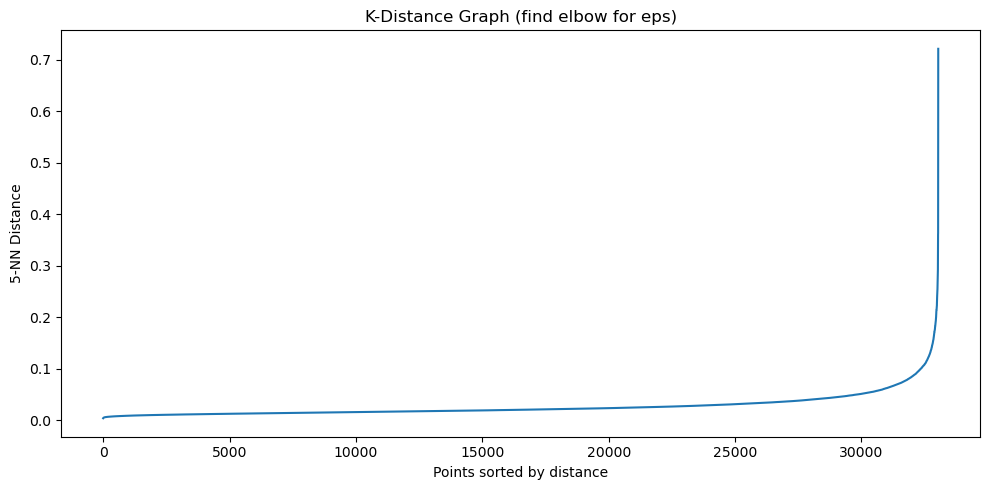

In [46]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_mm, n_neighbors=5)

In [47]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_mm, 2.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_mm, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


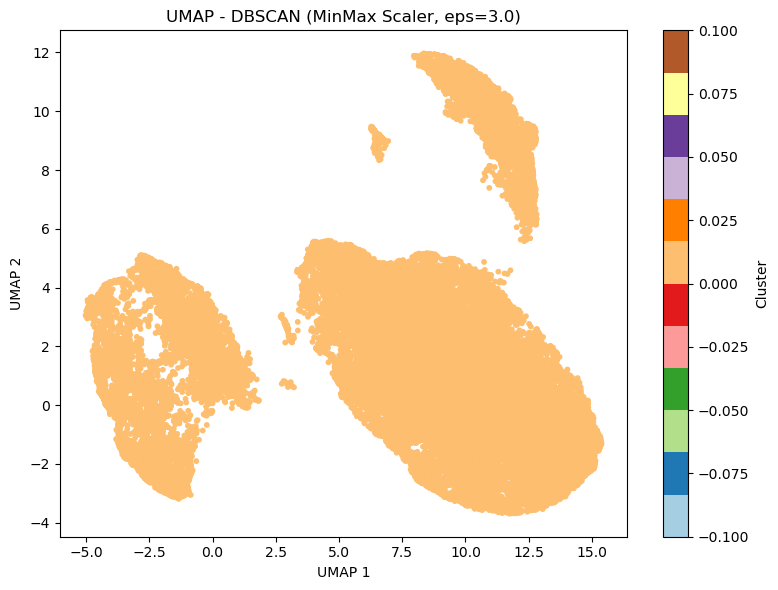

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [48]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_mm, labels_dbscan_mm = fit_dbscan(df_processed_mm, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_dbscan_mm, title="UMAP - DBSCAN (MinMax Scaler, eps=3.0)")

## 4.5 Self-Organizing Map (SOM)

In [49]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_mm = fit_som(df_processed_mm, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

KeyboardInterrupt: 

In [ ]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_mm = get_som_cluster_labels(som_result_mm['weights'], n_clusters=5, random_state=42)
print(neuron_labels_mm)

In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_mm, neuron_labels_mm = assign_som_clusters(som_result_mm['weights'], df_processed_mm, n_clusters=5, random_state=42)
print((labels_som_mm, neuron_labels_mm))